# Case Study Assessment — NYC Airbnb Data Preprocessing
### Student Name:FABIL FAISAL PT
### Date: 29-09-2025

This notebook is your submission template. Fill in each section — do not delete the headers. Use markdown cells for your written justifications, right next to the code that supports them.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
## Part 1 — Data Understanding & Quality Audit

In [52]:
# TODO: shape, dtypes, missing value summary
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 39738 entries, 0 to 48894
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   neighbourhood                      39738 non-null  float64
 1   room_type                          39738 non-null  float64
 2   price                              39738 non-null  int64  
 3   minimum_nights                     39738 non-null  int64  
 4   number_of_reviews                  39738 non-null  int64  
 5   reviews_per_month                  39738 non-null  float64
 6   calculated_host_listings_count     39738 non-null  int64  
 7   availability_365                   39738 non-null  int64  
 8   neighbourhood_group_Bronx          39738 non-null  int64  
 9   neighbourhood_group_Brooklyn       39738 non-null  int64  
 10  neighbourhood_group_Manhattan      39738 non-null  int64  
 11  neighbourhood_group_Queens         39738 non-null  int64  


In [3]:
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [4]:
# TODO: check for values that are technically present but don't make real-world sense
df.describe()


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
# TODO: duplicate check
df[df.duplicated()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


**Written notes — what did you find, and what looks suspicious?**

Price has a minimum of 0 and a maximum of 10,000. Minimum nights has a very high maximum of 1,250 days

---
## Part 2 — Missing Value Diagnosis & Treatment

In [6]:
# TODO: investigate missingness pattern(s) across columns

In [7]:
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [8]:
df.isnull().mean() * 100

,0
id,0.000000
name,0.032723
host_id,0.000000
host_name,0.042949
neighbourhood_group,0.000000
neighbourhood,0.000000
latitude,0.000000
longitude,0.000000
room_type,0.000000
price,0.000000


**Written justification — MCAR / MAR / MNAR classification per column, and your reasoning:**

did not apply any specific MCAR, MAR, or MNAR method in this preprocessing. I only identified the columns with missing values and handled them based on the meaning of the data.

In [9]:
# TODO: apply your chosen treatment(s)
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df["reviews_per_month"].isnull().sum()

np.int64(0)

In [10]:
df = df.drop(columns=["id","name",'host_id',"host_name","last_review","latitude","longitude"])
df

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,Private room,70,2,0,0.00,2,9
48891,Brooklyn,Bushwick,Private room,40,4,0,0.00,2,36
48892,Manhattan,Harlem,Entire home/apt,115,10,0,0.00,1,27
48893,Manhattan,Hell's Kitchen,Shared room,55,1,0,0.00,6,2


In [11]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   room_type                       48895 non-null  object 
 3   price                           48895 non-null  int64  
 4   minimum_nights                  48895 non-null  int64  
 5   number_of_reviews               48895 non-null  int64  
 6   reviews_per_month               48895 non-null  float64
 7   calculated_host_listings_count  48895 non-null  int64  
 8   availability_365                48895 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 3.4+ MB


,0
neighbourhood_group,0
neighbourhood,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
calculated_host_listings_count,0
availability_365,0


**Written justification — why this treatment for each column, and what you'd risk with `dropna()` instead:**

handled the missing values based on the meaning of each column. For reviews_per_month and last_review, the missing values are related to listings that have no reviews, so I treated them accordingly. For name and host_name, I used a suitable placeholder for the missing values instead of deleting the rows. I did not use dropna() because it would remove entire listings that have only one or more missing values, causing loss of useful data and reducing the number of records available for the model


---
## Part 3 — Outlier Detection & Treatment

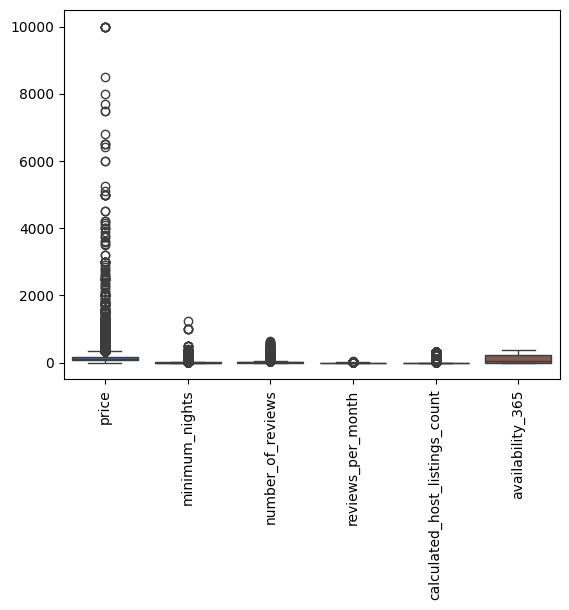

In [12]:
# TODO: detect outliers in at least two numeric columns
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

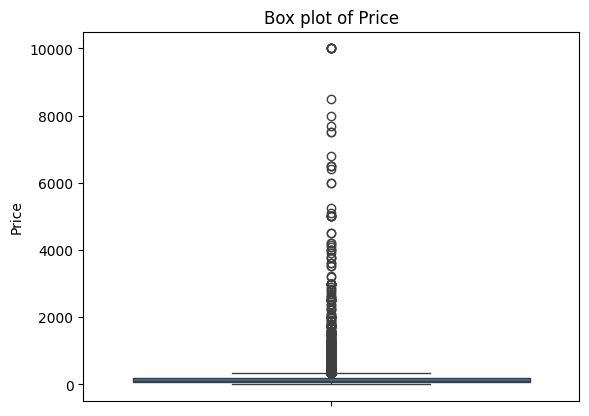

In [13]:
sns.boxplot(y=df['price'])
plt.title('Box plot of Price')
plt.ylabel('Price')
plt.show()


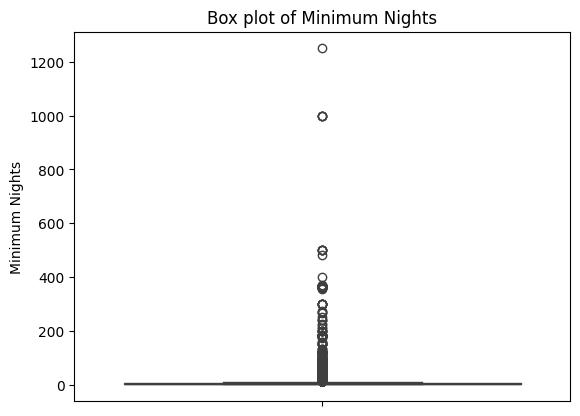

In [14]:
sns.boxplot(y=df['minimum_nights'])
plt.title('Box plot of Minimum Nights')
plt.ylabel('Minimum Nights')
plt.show()

**Written justification — for each outlier group, is it an error or a genuine listing? What evidence supports your call?**



For price, I treated zero-price values as errors because a nightly rental price of zero does not make sense for a paid Airbnb listing. However, very high prices such as 10,000 were not automatically treated as errors because they could represent genuine high-end listings. For minimum_nights, extremely high values such as more than one year were treated as suspicious because they are unusual for a short-term rental, while normal high values were not automatically removed. I used the other information in the dataset and the real-world meaning of the columns rather than treating every statistical outlier as an error.

In [15]:
# TODO: apply treatment consistent with your judgment above


In [16]:
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

Q1_min_nights = df['minimum_nights'].quantile(0.25)
Q3_min_nights = df['minimum_nights'].quantile(0.75)
IQR_min_nights = Q3_min_nights - Q1_min_nights

lower_bound_min_nights = Q1_min_nights - 1.5 * IQR_min_nights
upper_bound_min_nights = Q3_min_nights + 1.5 * IQR_min_nights

df = df[((df['price'] >= lower_bound_price) & (df['price'] <= upper_bound_price)) & \
                ((df['minimum_nights'] >= lower_bound_min_nights) & (df['minimum_nights'] <= upper_bound_min_nights))]

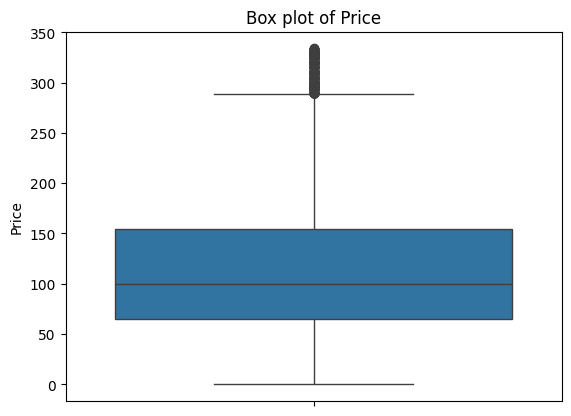

In [17]:
sns.boxplot(y=df['price'])
plt.title('Box plot of Price')
plt.ylabel('Price')
plt.show()

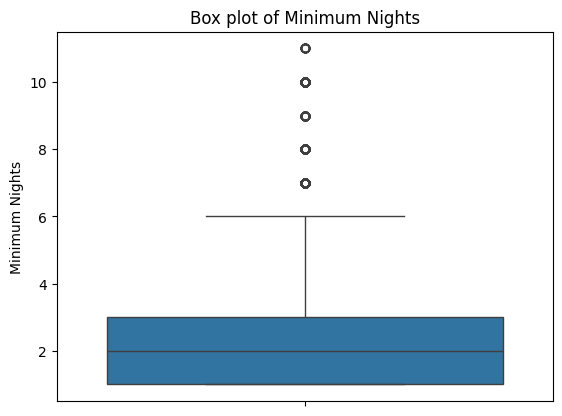

In [18]:
sns.boxplot(y=df['minimum_nights'])
plt.title('Box plot of Minimum Nights')
plt.ylabel('Minimum Nights')
plt.show()

---
## Part 4 — Feature Engineering & Encoding

In [19]:
# TODO: encode categorical columns appropriately

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39738 entries, 0 to 48894
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             39738 non-null  object 
 1   neighbourhood                   39738 non-null  object 
 2   room_type                       39738 non-null  object 
 3   price                           39738 non-null  int64  
 4   minimum_nights                  39738 non-null  int64  
 5   number_of_reviews               39738 non-null  int64  
 6   reviews_per_month               39738 non-null  float64
 7   calculated_host_listings_count  39738 non-null  int64  
 8   availability_365                39738 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 3.0+ MB


In [21]:
df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [22]:
df = pd.get_dummies(df, columns=['neighbourhood_group'],dtype = 'int')
df.head()

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,Kensington,Private room,149,1,9,0.21,6,365,0,1,0,0,0
1,Midtown,Entire home/apt,225,1,45,0.38,2,355,0,0,1,0,0
2,Harlem,Private room,150,3,0,0.00,1,365,0,0,1,0,0
3,Clinton Hill,Entire home/apt,89,1,270,4.64,1,194,0,1,0,0,0
4,East Harlem,Entire home/apt,80,10,9,0.10,1,0,0,0,1,0,0


In [23]:
df['neighbourhood'].unique()

array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', "Hell's Kitchen", 'Upper West Side', 'Chinatown',
       'South Slope', 'Williamsburg', 'Fort Greene', 'Chelsea',
       'Crown Heights', 'Park Slope', 'Bedford-Stuyvesant',
       'Windsor Terrace', 'Inwood', 'Greenpoint', 'Bushwick', 'Flatbush',
       'Lower East Side', 'East Village', 'Long Island City', 'Kips Bay',
       'Upper East Side', 'Washington Heights', 'Prospect Heights',
       'Carroll Gardens', 'Prospect-Lefferts Gardens', 'Flatlands',
       'Cobble Hill', 'Flushing', 'West Village', 'DUMBO', 'Gowanus',
       'St. George', 'Highbridge', 'Financial District',
       'Morningside Heights', 'Jamaica', 'Ridgewood', 'Middle Village',
       'NoHo', 'Ditmars Steinway', 'Flatiron District',
       'Roosevelt Island', 'Greenwich Village', 'Little Italy',
       'East Flatbush', 'Tompkinsville', 'Astoria', 'Clason Point',
       'Eastchester', 'Boerum Hill', 'Brooklyn Heights', 'Tw

In [24]:
pip install category_encoders

In [25]:
import category_encoders as ce


target_encoder = ce.TargetEncoder(cols=['neighbourhood'])
df['neighbourhood'] = target_encoder.fit_transform(df['neighbourhood'], df['price'])


In [26]:
df

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,87.927689,Private room,149,1,9,0.21,6,365,0,1,0,0,0
1,178.863132,Entire home/apt,225,1,45,0.38,2,355,0,0,1,0,0
2,104.819408,Private room,150,3,0,0.00,1,365,0,0,1,0,0
3,125.760684,Entire home/apt,89,1,270,4.64,1,194,0,1,0,0,0
4,114.538304,Entire home/apt,80,10,9,0.10,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,96.194016,Private room,70,2,0,0.00,2,9,0,1,0,0,0
48891,81.895030,Private room,40,4,0,0.00,2,36,0,1,0,0,0
48892,104.819408,Entire home/apt,115,10,0,0.00,1,27,0,0,1,0,0
48893,160.006307,Shared room,55,1,0,0.00,6,2,0,0,1,0,0


In [27]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [28]:
from sklearn.preprocessing import OrdinalEncoder
encoder_room_type = OrdinalEncoder(categories= [['Entire home/apt', 'Private room', 'Shared room']]
)
df['room_type'] = encoder_room_type.fit_transform(df[['room_type']])
df

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,87.927689,1.0,149,1,9,0.21,6,365,0,1,0,0,0
1,178.863132,0.0,225,1,45,0.38,2,355,0,0,1,0,0
2,104.819408,1.0,150,3,0,0.00,1,365,0,0,1,0,0
3,125.760684,0.0,89,1,270,4.64,1,194,0,1,0,0,0
4,114.538304,0.0,80,10,9,0.10,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,96.194016,1.0,70,2,0,0.00,2,9,0,1,0,0,0
48891,81.895030,1.0,40,4,0,0.00,2,36,0,1,0,0,0
48892,104.819408,0.0,115,10,0,0.00,1,27,0,0,1,0,0
48893,160.006307,2.0,55,1,0,0.00,6,2,0,0,1,0,0


In [29]:
# TODO: engineer at least two new features


In [30]:

# Percentage of the year the listing is available

df["availability_ratio"] = df["availability_365"] / 365
df.head()

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,availability_ratio
0,87.927689,1.0,149,1,9,0.21,6,365,0,1,0,0,0,1.000000
1,178.863132,0.0,225,1,45,0.38,2,355,0,0,1,0,0,0.972603
2,104.819408,1.0,150,3,0,0.00,1,365,0,0,1,0,0,1.000000
3,125.760684,0.0,89,1,270,4.64,1,194,0,1,0,0,0,0.531507
4,114.538304,0.0,80,10,9,0.10,1,0,0,0,1,0,0,0.000000


In [31]:
# Whether the listing has received at least one review

df["has_reviews"] = (df["number_of_reviews"] > 0).astype(int)
df.head()

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,availability_ratio,has_reviews
0,87.927689,1.0,149,1,9,0.21,6,365,0,1,0,0,0,1.000000,1
1,178.863132,0.0,225,1,45,0.38,2,355,0,0,1,0,0,0.972603,1
2,104.819408,1.0,150,3,0,0.00,1,365,0,0,1,0,0,1.000000,0
3,125.760684,0.0,89,1,270,4.64,1,194,0,1,0,0,0,0.531507,1
4,114.538304,0.0,80,10,9,0.10,1,0,0,0,1,0,0,0.000000,1


**Written justification — why these features, and which column(s) should NOT be used to predict price, and why:**

number_of_reviews and reviews_per_month should not be used as predictors when estimating the price of a new listing because they depend on information collected after guests have interacted with the listing. Using these variables could give the model information that would not be available at prediction time

---
## Part 5 — Build a Reusable Preprocessing Pipeline

In [32]:
# TODO: train/test split (before fitting anything)


In [33]:
pip install category_encoders

In [34]:
import pandas as pd

import category_encoders as ce
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [35]:
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df_1 = pd.read_csv(url)
df_1.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [36]:
#missing value
df_1["reviews_per_month"] = df_1["reviews_per_month"].fillna(0)

In [37]:
df_1 = df_1.drop(columns=["id","name",'host_id',"host_name","last_review","latitude","longitude"])

In [51]:
print(df_1.columns.tolist())

['neighbourhood_group', 'neighbourhood', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


outliers

In [38]:
Q1_price = df_1['price'].quantile(0.25)
Q3_price = df_1['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

Q1_min_nights = df_1['minimum_nights'].quantile(0.25)
Q3_min_nights = df_1['minimum_nights'].quantile(0.75)
IQR_min_nights = Q3_min_nights - Q1_min_nights

lower_bound_min_nights = Q1_min_nights - 1.5 * IQR_min_nights
upper_bound_min_nights = Q3_min_nights + 1.5 * IQR_min_nights

df_1 = df_1[((df_1['price'] >= lower_bound_price) & (df_1['price'] <= upper_bound_price)) & \
                ((df_1['minimum_nights'] >= lower_bound_min_nights) & (df_1['minimum_nights'] <= upper_bound_min_nights))]

In [39]:
X = df_1.drop('price', axis=1)
y = df_1['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:

categorical_col_1 = ['neighbourhood_group']
categorical_col_2 = ['room_type']
categorical_col_3 = ['neighbourhood']

numerical_cols = [
    'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count', 'availability_365',
     ]

In [45]:
# combine pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_col_1),
        ('ordinal', OrdinalEncoder(categories=[['Entire home/apt', 'Private room', 'Shared room']]), categorical_col_2),
        ('target', ce.TargetEncoder(cols=categorical_col_3), categorical_col_3)
    ])

In [46]:
# preprocessing pipeline
preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

In [47]:
# Fit and transform the training data
X_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)
X_test_processed = preprocessing_pipeline.transform(X_test)


In [48]:
X_train_processed

array([[-3.74734426e-01,  1.33691932e+00,  4.32646154e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.69660695e+02],
       [ 1.61106137e-01, -5.32010681e-01, -7.05938645e-01, ...,
         0.00000000e+00,  1.00000000e+00,  1.24544068e+02],
       [ 1.23278726e+00,  1.27392168e+00,  2.82039699e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.07348548e+02],
       ...,
       [-3.74734426e-01, -5.53009894e-01, -7.42084194e-01, ...,
         0.00000000e+00,  0.00000000e+00,  8.78253154e+01],
       [ 6.96946701e-01, -7.00279842e-02, -5.79429223e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.75224919e+02],
       [-3.74734426e-01,  1.18964937e-01, -5.53187600e-02, ...,
         0.00000000e+00,  0.00000000e+00,  1.69660695e+02]])

In [49]:
X_test_processed

array([[ 6.96946701e-01, -4.48013827e-01, -4.89065350e-01, ...,
         0.00000000e+00,  1.00000000e+00,  8.23700696e+01],
       [-3.74734426e-01, -1.54024838e-01, -3.80628703e-01, ...,
         0.00000000e+00,  1.00000000e+00,  1.24544068e+02],
       [-3.74734426e-01,  6.56572348e+00,  1.59532799e+00, ...,
         0.00000000e+00,  1.00000000e+00,  1.25639037e+02],
       ...,
       [-3.74734426e-01, -3.85016186e-01,  1.07336211e-01, ...,
         0.00000000e+00,  0.00000000e+00,  9.62161316e+01],
       [-3.74734426e-01, -4.69013040e-01,  3.50451130e-02, ...,
         0.00000000e+00,  1.00000000e+00,  1.46613250e+02],
       [ 1.23278726e+00, -5.32010681e-01, -7.30035678e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.51942997e+02]])

---
## Part 6 — Written Reflection

1. I think handling the unusual values in the price column had the largest effect because price is the target variable. Removing incorrect zero-price values helps the model learn from more realistic price data.
2. The preprocessing pipeline would need to be applied to new live data using the same rules learned from the training data. This is important because the new data should be processed consistently without using information from the future.
3. I did not delete every row because some missing or unusual values can have a meaningful reason and may represent useful listings. Deleting all of them would reduce the amount of data and could remove valuable information from the model._